# 다보험 가입자의 'Lock-in' 효과 (Multi-policy Loyalty)
- 여러 개의 보험을 가진 고객(multi_policy_flag == 1)은 단일 보험 가입자보다 이탈률이 낮을 것이다.
- 특히 Auto와 Home을 결합한 경우 이탈률이 가장 낮을 것이다.
- 관련 컬럼: policy_type, multi_policy_flag, num_policies, churn_flag
- 분석 포인트: 가입한 보험 개수(num_policies)에 따른 이탈률 하락 곡선을 그립니다.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_data

In [3]:
# 1. 데이터 로드
df = load_data()
df.head()

,customer_id,as_of_date,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,...,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag,churn_type,churn_probability_true
0,1,2025-12-31,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,...,7,1616,0,0,0,0,0,0,No churn,0.048626
1,2,2025-12-31,Auckland,70,65-74,Married,76,1,3,Auto,...,15,1760,1,0,0,0,0,0,No churn,0.067888
2,3,2025-12-31,Bay of Plenty,62,55-64,Married,129,0,1,Auto,...,24,1581,1,0,0,0,0,0,No churn,0.223765
3,4,2025-12-31,Bay of Plenty,47,45-54,Single,104,0,1,Auto,...,17,1688,1,0,0,0,0,0,No churn,0.602455
4,5,2025-12-31,Bay of Plenty,47,45-54,Married,22,1,3,Life,...,24,1592,1,0,0,0,0,0,No churn,0.050723


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  50000 non-null  int64  
 1   as_of_date                   50000 non-null  object 
 2   region_name                  50000 non-null  object 
 3   age                          50000 non-null  int64  
 4   age_band                     50000 non-null  object 
 5   marital_status               50000 non-null  object 
 6   customer_tenure_months       50000 non-null  int64  
 7   multi_policy_flag            50000 non-null  int64  
 8   num_policies                 50000 non-null  int64  
 9   policy_type                  50000 non-null  object 
 10  renewal_month                50000 non-null  int64  
 11  current_premium              50000 non-null  float64
 12  premium_last_year            50000 non-null  float64
 13  premium_change_p

In [5]:
# [전처리 1] 이상치 처리: 보험 개수가 극단적으로 많은 고객 처리
# 10개 이상인 고객을 확인하고, 분석의 왜곡을 막기 위해 10개로 클리핑(Clipping)하거나 제외합니다.
# 여기서는 10개 이상을 '10+' 그룹으로 간주하거나 상한선을 두는 방식을 사용합니다.
upper_limit = 10
df['num_policies_cleaned'] = df['num_policies'].apply(lambda x: x if x < upper_limit else upper_limit)

print(f"이상치 처리 전 최대 보험 개수: {df['num_policies'].max()}")
print(f"이상치 처리 후 최대 보험 개수: {df['num_policies_cleaned'].max()}\n")

# [전처리 2] 파생 변수 생성: 다보험 기반 Auto/Home 결합 잠재군 (has_auto_home_potential)
# 조건: 보험 개수가 2개 이상(multi_policy_flag == 1)이면서
# 현재 policy_type이 'Auto' 또는 'Home'인 경우를 1로 분류

def classify_auto_home_group(row):
    if row['multi_policy_flag'] == 1 and row['policy_type'] in ['Auto', 'Home']:
        return 1
    else:
        return 0

df['has_auto_home_potential'] = df.apply(classify_auto_home_group, axis=1)

print("--- 파생 변수 생성 완료 (has_auto_home_potential) ---")
print(df['has_auto_home_potential'].value_counts())

이상치 처리 전 최대 보험 개수: 4
이상치 처리 후 최대 보험 개수: 4

--- 파생 변수 생성 완료 (has_auto_home_potential) ---
has_auto_home_potential
0    41095
1     8905
Name: count, dtype: int64


--- 다보험 가입 여부별 이탈률 ---
multi_policy_flag
0    0.37070
1    0.15403
Name: churn_flag, dtype: float64


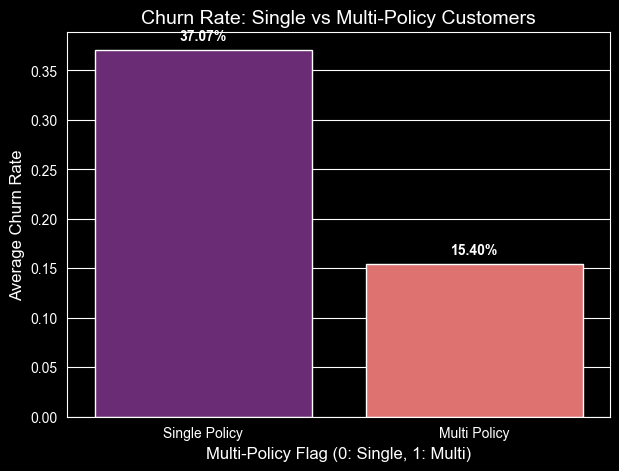

In [6]:
# 2. 다보험 가입 여부(multi_policy_flag)에 따른 평균 이탈률 비교
multi_policy_churn = df.groupby('multi_policy_flag')['churn_flag'].mean()
print("--- 다보험 가입 여부별 이탈률 ---")
print(multi_policy_churn)

# 시각화: 다보험 가입 여부(0 또는 1)에 따른 이탈률 비교
plt.figure(figsize=(7, 5))

# palette 사용 시 x와 동일한 값을 hue에 넣어주어야 최신 문법에 맞습니다.
sns.barplot(
    x=multi_policy_churn.index,
    y=multi_policy_churn.values,
    hue=multi_policy_churn.index, # x와 동일하게 설정
    palette='magma',
    legend=False                  # 범례는 필요 없으므로 숨김
)

plt.title("Churn Rate: Single vs Multi-Policy Customers", fontsize=14)
plt.xlabel("Multi-Policy Flag (0: Single, 1: Multi)", fontsize=12)
plt.ylabel("Average Churn Rate", fontsize=12)
plt.xticks([0, 1], ['Single Policy', 'Multi Policy'])

# 막대 위에 숫자 표시
for i, val in enumerate(multi_policy_churn.values):
    plt.text(i, val + 0.01, f'{val:.2%}', ha='center', fontweight='bold')

plt.show()

   num_policies  churn_flag
0             1    0.370700
1             2    0.144505
2             3    0.158592
3             4    0.158926


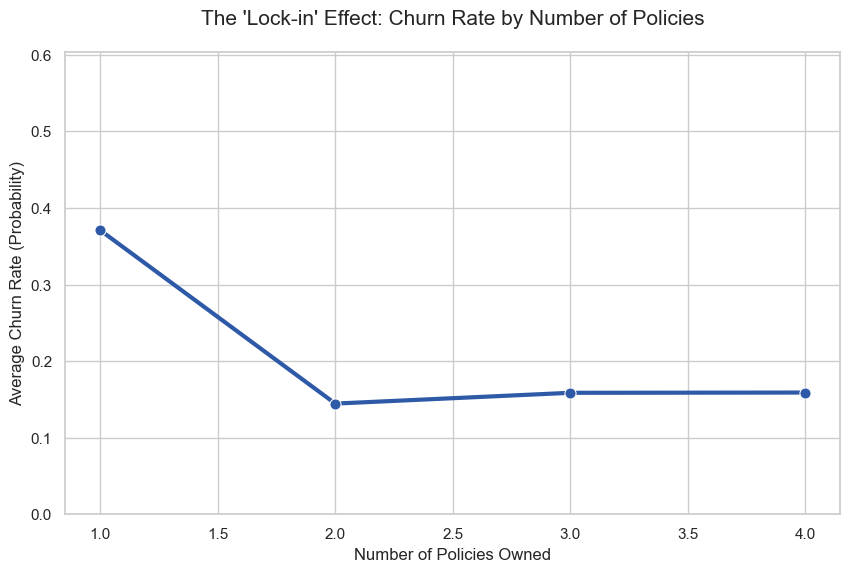

In [7]:
# 3. 가입 보험 개수(num_policies)에 따른 이탈률 계산
policy_churn = df.groupby('num_policies')['churn_flag'].mean().reset_index()

print(policy_churn)

# 시각화 스타일 설정 (깔끔한 화이트 배경)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# 라인플롯으로 추세 확인 (Lock-in 효과 증명)
sns.lineplot(
    data=policy_churn,
    x='num_policies',
    y='churn_flag',
    marker='o',
    markersize=8,
    linewidth=3,
    color='#2E59A7'
)

plt.title("The 'Lock-in' Effect: Churn Rate by Number of Policies", fontsize=15, pad=20)
plt.xlabel("Number of Policies Owned", fontsize=12)
plt.ylabel("Average Churn Rate (Probability)", fontsize=12)

# Y축 범위를 데이터 평균의 2배 정도로 설정하여 가시성 확보
plt.ylim(0, df['churn_flag'].mean() * 2)

plt.show()


--- 잠재 결합군 vs 일반군 이탈률 비교 ---
has_auto_home_potential
0    0.333252
1    0.155867
Name: churn_flag, dtype: float64


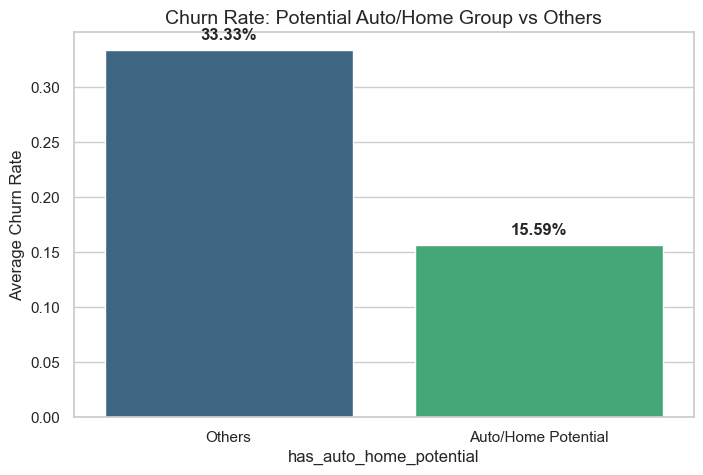

In [8]:
# 5. [심화] Auto 혹은 Home 보험 소유 고객 확인 (가설의 두 번째 포인트)
# 각 그룹별 이탈률 비교
potential_churn_rate = df.groupby('has_auto_home_potential')['churn_flag'].mean()
print("\n--- 잠재 결합군 vs 일반군 이탈률 비교 ---")
print(potential_churn_rate)

# 시각화: 잠재 결합군 여부에 따른 이탈률 차이
plt.figure(figsize=(8, 5))
# hue를 설정하여 경고를 방지하고 시각적 명확성을 높임
sns.barplot(
    x=potential_churn_rate.index,
    y=potential_churn_rate.values,
    hue=potential_churn_rate.index,
    palette='viridis',
    legend=False
)

plt.title('Churn Rate: Potential Auto/Home Group vs Others', fontsize=14)
plt.xticks([0, 1], ['Others', 'Auto/Home Potential'])
plt.ylabel('Average Churn Rate')

# 막대 위에 이탈률 수치 표시
for i, val in enumerate(potential_churn_rate.values):
    plt.text(i, val + 0.01, f'{val:.2%}', ha='center', fontweight='bold')

plt.show()